In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

In [2]:
num_students = 500
num_days = 180

students = [f"S{i:04d}" for i in range(1, num_students + 1)]
dates = pd.date_range(end=pd.Timestamp.today(), periods=num_days)

activity_data = []

for student in students:
    base_engagement = np.random.randint(35, 85)
    
    for date in dates:
        attendance = np.random.choice([0, 1], p=[0.25, 0.75])
        engagement = max(
            0,
            base_engagement
            + np.random.randint(-20, 20)
            - (attendance == 0) * np.random.randint(15, 30)
        )

        activity_data.append([
            student,
            date,
            np.random.randint(1, 15),
            attendance,
            engagement
        ])

activity_df = pd.DataFrame(
    activity_data,
    columns=[
        "student_id",
        "date",
        "lecture_id",
        "attendance",
        "engagement_score"
    ]
)

activity_df.shape

(90000, 5)

In [3]:
topics = [
    "Linear Algebra", "Probability", "Statistics",
    "ML Basics", "Deep Learning", "NLP",
    "Computer Vision", "Optimization"
]

quiz_data = []

for student in students:
    for topic in topics:
        attempts = np.random.randint(2, 5)
        for _ in range(attempts):
            score = np.random.randint(25, 100)
            quiz_data.append([
                student,
                f"QZ_{topic[:3].upper()}",
                topic,
                score,
                100,
                np.random.choice(dates)
            ])

quiz_df = pd.DataFrame(
    quiz_data,
    columns=[
        "student_id",
        "quiz_id",
        "topic",
        "score",
        "max_score",
        "date"
    ]
)

quiz_df.shape


(12017, 6)

In [4]:
doubt_data = []

for student in students:
    for topic in topics:
        doubt_data.append([
            student,
            topic,
            np.random.poisson(lam=4),
            np.random.choice(dates)
        ])

doubt_df = pd.DataFrame(
    doubt_data,
    columns=[
        "student_id",
        "topic",
        "question_count",
        "date"
    ]
)

doubt_df.shape


(4000, 4)

In [5]:
activity_df.to_csv("../data/analytics/student_activity.csv", index=False)
quiz_df.to_csv("../data/analytics/quiz_performance.csv", index=False)
doubt_df.to_csv("../data/analytics/doubt_interactions.csv", index=False)

print("✅ Phase 2 datasets saved successfully")

✅ Phase 2 datasets saved successfully


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
activity_df = pd.read_csv("../data/analytics/student_activity.csv", parse_dates=["date"])
quiz_df = pd.read_csv("../data/analytics/quiz_performance.csv", parse_dates=["date"])
doubt_df = pd.read_csv("../data/analytics/doubt_interactions.csv", parse_dates=["date"])

activity_df.head()


,student_id,date,lecture_id,attendance,engagement_score
0,S0001,2025-07-21 13:55:37.168988,8,1,67
1,S0001,2025-07-22 13:55:37.168988,3,1,91
2,S0001,2025-07-23 13:55:37.168988,5,0,41
3,S0001,2025-07-24 13:55:37.168988,6,1,76
4,S0001,2025-07-25 13:55:37.168988,14,0,50


In [7]:
attendance_trend = (
    activity_df
    .groupby("date")["attendance"]
    .mean()
    .reset_index()
)

attendance_trend.head()


,date,attendance
0,2025-07-21 13:55:37.168988,0.750
1,2025-07-22 13:55:37.168988,0.764
2,2025-07-23 13:55:37.168988,0.746
3,2025-07-24 13:55:37.168988,0.754
4,2025-07-25 13:55:37.168988,0.776


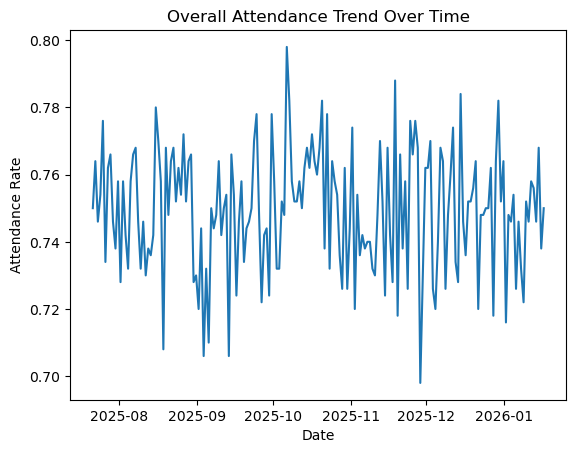

In [8]:
plt.figure()
plt.plot(attendance_trend["date"], attendance_trend["attendance"])
plt.title("Overall Attendance Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Attendance Rate")
plt.show()


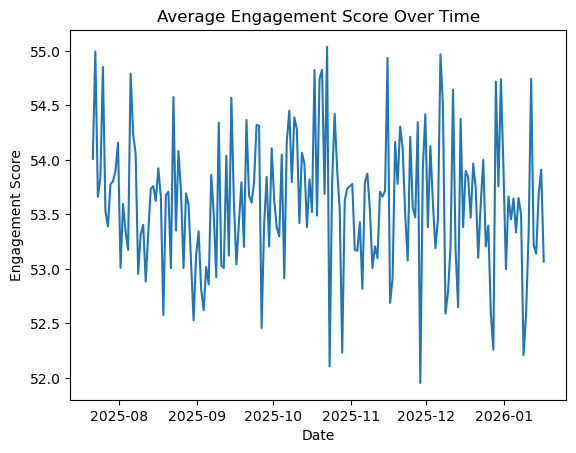

In [9]:
engagement_trend = (
    activity_df
    .groupby("date")["engagement_score"]
    .mean()
    .reset_index()
)

plt.figure()
plt.plot(engagement_trend["date"], engagement_trend["engagement_score"])
plt.title("Average Engagement Score Over Time")
plt.xlabel("Date")
plt.ylabel("Engagement Score")
plt.show()


In [10]:
topic_performance = (
    quiz_df
    .groupby("topic")["score"]
    .mean()
    .sort_values()
)

topic_performance


topic
ML Basics          60.893534
Deep Learning      61.550340
Optimization       61.714286
Computer Vision    61.852744
Statistics         62.067922
NLP                62.267419
Linear Algebra     62.272244
Probability        62.333769
Name: score, dtype: float64

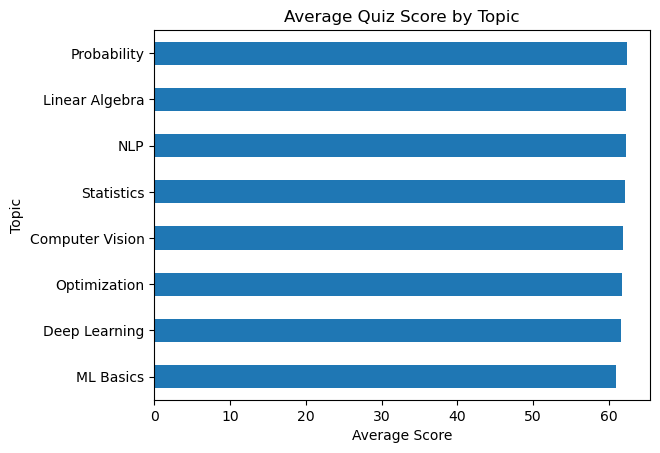

In [11]:
plt.figure()
topic_performance.plot(kind="barh")
plt.title("Average Quiz Score by Topic")
plt.xlabel("Average Score")
plt.ylabel("Topic")
plt.show()


In [12]:
# Aggregate activity features per student
activity_features = (
    activity_df
    .groupby("student_id")
    .agg(
        avg_attendance=("attendance", "mean"),
        avg_engagement=("engagement_score", "mean")
    )
    .reset_index()
)

# Aggregate quiz features per student
quiz_features = (
    quiz_df
    .groupby("student_id")
    .agg(
        avg_quiz_score=("score", "mean")
    )
    .reset_index()
)

# Merge features
student_features = pd.merge(
    activity_features,
    quiz_features,
    on="student_id"
)

student_features.head()


,student_id,avg_attendance,avg_engagement,avg_quiz_score
0,S0001,0.761111,68.127778,64.347826
1,S0002,0.738889,48.333333,63.086957
2,S0003,0.716667,44.038889,63.615385
3,S0004,0.711111,62.305556,63.083333
4,S0005,0.766667,52.383333,53.916667


In [19]:
# Normalize features (0–1 scale)
student_features["att_norm"] = (
    student_features["avg_attendance"] - student_features["avg_attendance"].min()
) / (student_features["avg_attendance"].max() - student_features["avg_attendance"].min())

student_features["eng_norm"] = (
    student_features["avg_engagement"] - student_features["avg_engagement"].min()
) / (student_features["avg_engagement"].max() - student_features["avg_engagement"].min())

student_features["quiz_norm"] = (
    student_features["avg_quiz_score"] - student_features["avg_quiz_score"].min()
) / (student_features["avg_quiz_score"].max() - student_features["avg_quiz_score"].min())


# Risk score (higher = more risk)
student_features["risk_score"] = (
    (1 - student_features["att_norm"]) +
    (1 - student_features["eng_norm"]) +
    (1 - student_features["quiz_norm"])
) / 3


# Label top 30% as at-risk
risk_threshold = student_features["risk_score"].quantile(0.70)

student_features["at_risk"] = (
    student_features["risk_score"] >= risk_threshold
).astype(int)

student_features["at_risk"].value_counts()


at_risk
0    350
1    150
Name: count, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

X = student_features[
    ["avg_attendance", "avg_engagement", "avg_quiz_score"]
]
y = student_features["at_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((375, 3), (125, 3))

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [22]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[76 12]
 [ 7 30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89        88
           1       0.71      0.81      0.76        37

    accuracy                           0.85       125
   macro avg       0.81      0.84      0.82       125
weighted avg       0.86      0.85      0.85       125



In [23]:
from sklearn.metrics import roc_auc_score, roc_curve

y_probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)

auc


np.float64(0.9238329238329238)

In [24]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient")

feature_importance


,feature,coefficient
0,avg_attendance,-1.978141
2,avg_quiz_score,-0.290848
1,avg_engagement,-0.192453


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_pred))


Confusion Matrix (Random Forest):
[[83  5]
 [ 3 34]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        88
           1       0.87      0.92      0.89        37

    accuracy                           0.94       125
   macro avg       0.92      0.93      0.92       125
weighted avg       0.94      0.94      0.94       125



In [27]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, rf_probs)

print("Logistic Regression AUC:", auc)
print("Random Forest AUC:", rf_auc)


Logistic Regression AUC: 0.9238329238329238
Random Forest AUC: 0.9883292383292384


In [28]:
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=True)

rf_importance

,feature,importance
2,avg_quiz_score,0.202068
0,avg_attendance,0.249610
1,avg_engagement,0.548322


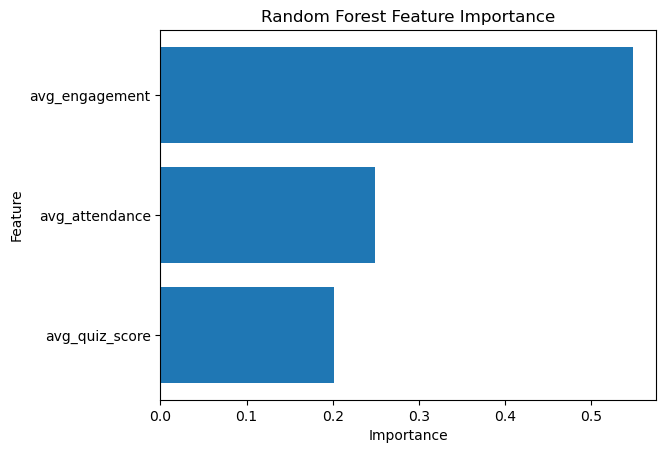

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(rf_importance["feature"], rf_importance["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [30]:
topic_quiz = (
    quiz_df
    .groupby("topic")["score"]
    .mean()
    .reset_index(name="avg_quiz_score")
)

topic_quiz

,topic,avg_quiz_score
0,Computer Vision,61.852744
1,Deep Learning,61.550340
2,Linear Algebra,62.272244
3,ML Basics,60.893534
4,NLP,62.267419
5,Optimization,61.714286
6,Probability,62.333769
7,Statistics,62.067922


In [31]:
topic_doubts = (
    doubt_df
    .groupby("topic")["question_count"]
    .mean()
    .reset_index(name="avg_doubts")
)

topic_doubts

,topic,avg_doubts
0,Computer Vision,3.928
1,Deep Learning,4.030
2,Linear Algebra,3.944
3,ML Basics,3.996
4,NLP,3.936
5,Optimization,4.062
6,Probability,3.920
7,Statistics,3.938


In [32]:
np.random.seed(42)

topic_recall = pd.DataFrame({
    "topic": topic_quiz["topic"],
    "recall_rate": np.random.uniform(0.55, 0.9, size=len(topic_quiz))
})

topic_recall

,topic,recall_rate
0,Computer Vision,0.681089
1,Deep Learning,0.882750
2,Linear Algebra,0.806198
3,ML Basics,0.759530
4,NLP,0.604607
5,Optimization,0.604598
6,Probability,0.570329
7,Statistics,0.853162


In [33]:
topic_metrics = (
    topic_quiz
    .merge(topic_doubts, on="topic")
    .merge(topic_recall, on="topic")
)

topic_metrics

,topic,avg_quiz_score,avg_doubts,recall_rate
0,Computer Vision,61.852744,3.928,0.681089
1,Deep Learning,61.550340,4.030,0.882750
2,Linear Algebra,62.272244,3.944,0.806198
3,ML Basics,60.893534,3.996,0.759530
4,NLP,62.267419,3.936,0.604607
5,Optimization,61.714286,4.062,0.604598
6,Probability,62.333769,3.920,0.570329
7,Statistics,62.067922,3.938,0.853162


In [34]:
topic_metrics["quiz_norm"] = (
    topic_metrics["avg_quiz_score"].max() - topic_metrics["avg_quiz_score"]
) / (topic_metrics["avg_quiz_score"].max() - topic_metrics["avg_quiz_score"].min())

topic_metrics["doubt_norm"] = (
    topic_metrics["avg_doubts"] - topic_metrics["avg_doubts"].min()
) / (topic_metrics["avg_doubts"].max() - topic_metrics["avg_doubts"].min())

topic_metrics["recall_norm"] = (
    topic_metrics["recall_rate"].max() - topic_metrics["recall_rate"]
) / (topic_metrics["recall_rate"].max() - topic_metrics["recall_rate"].min())

In [35]:
topic_metrics["difficulty_score"] = (
    topic_metrics["quiz_norm"]
    + topic_metrics["doubt_norm"]
    + topic_metrics["recall_norm"]
) / 3

topic_metrics.sort_values("difficulty_score", ascending=False)

,topic,avg_quiz_score,avg_doubts,recall_rate,quiz_norm,doubt_norm,recall_norm,difficulty_score
5,Optimization,61.714286,4.062,0.604598,0.430126,1.000000,0.890312,0.773479
3,ML Basics,60.893534,3.996,0.759530,1.000000,0.535211,0.394403,0.643205
1,Deep Learning,61.550340,4.030,0.882750,0.543959,0.774648,0.000000,0.439536
4,NLP,62.267419,3.936,0.604607,0.046069,0.112676,0.890285,0.349677
0,Computer Vision,61.852744,3.928,0.681089,0.333990,0.056338,0.645479,0.345269
6,Probability,62.333769,3.920,0.570329,0.000000,0.000000,1.000000,0.333333
2,Linear Algebra,62.272244,3.944,0.806198,0.042718,0.169014,0.245029,0.152254
7,Statistics,62.067922,3.938,0.853162,0.184586,0.126761,0.094707,0.135351


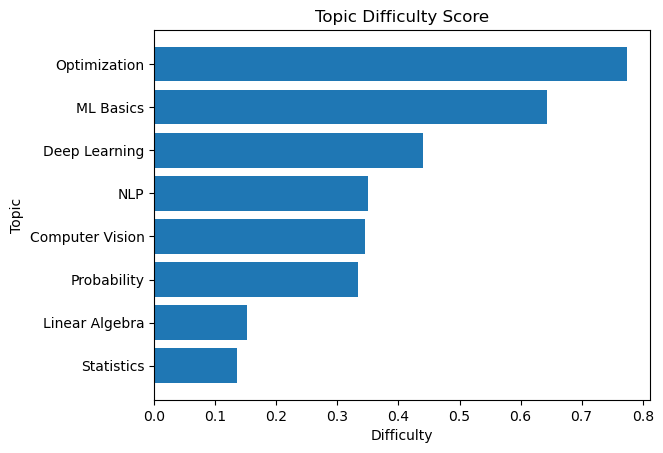

In [36]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(
    topic_metrics.sort_values("difficulty_score")["topic"],
    topic_metrics.sort_values("difficulty_score")["difficulty_score"]
)
plt.title("Topic Difficulty Score")
plt.xlabel("Difficulty")
plt.ylabel("Topic")
plt.show()   

In [37]:
# Load student risk data (reuse student_features)
student_risk = student_features.copy()

# Load topic difficulty (reuse topic_metrics)
topic_difficulty = topic_metrics.sort_values(
    "difficulty_score", ascending=False
)

# Top difficult topics
top_difficult_topics = topic_difficulty["topic"].head(2).tolist()

def generate_recommendation(row):
    recs = []

    if row["at_risk"] == 1:
        recs.append("Increase class attendance and engagement levels.")

    recs.append(
        f"Focus more on these difficult topics: {', '.join(top_difficult_topics)}."
    )

    return " ".join(recs)

student_risk["recommendation"] = student_risk.apply(
    generate_recommendation, axis=1
)

student_risk[["student_id", "at_risk", "recommendation"]].head()

,student_id,at_risk,recommendation
0,S0001,0,Focus more on these difficult topics: Optimiza...
1,S0002,0,Focus more on these difficult topics: Optimiza...
2,S0003,1,Increase class attendance and engagement level...
3,S0004,0,Focus more on these difficult topics: Optimiza...
4,S0005,1,Increase class attendance and engagement level...


In [38]:
student_risk[
    ["student_id", "at_risk", "recommendation"]
].to_csv(
    "../data/analytics/student_recommendations.csv",
    index=False
)

print("✅ Personalized recommendations saved")

✅ Personalized recommendations saved
